# Lab 062 · Trace the original TabPFN

[Lesson](../lessons/0062-tabpfn-v1.html) · [Reference](../reference/0062-tabpfn-v1.html) · [Reproduction contract](l062-reproduction.md)

**Route:** retrieve → explain → predict → implement → CHECK → inspect evidence → EXIT. PROVIDED cells are readable implementation and peripheral support. TODOs contain your load-bearing code; CHECKs give immediate diagnostic feedback. Complete the code before revealing teacher solutions. Core study: 35–50 minutes; lab: 45–75 minutes plus explicitly gated larger runs.

**Before reading:** May an unrelated query become a context key for another query in this mask? Write your answer and justify the information boundary. Then recall one older lesson that could expose an error in this experiment.

**Evidence contract:** numerical figures labeled author-reference come from committed author measurements. They are not outputs of your current kernel. Reduced model mechanisms, pretrained reference inference, frozen-result reanalysis and paper reproduction are different tracks. Every track states its scope below.

### Running on Google Colab?

Colab opens only this single file, so the course package (`relkit`) and the lab
dependencies (xgboost, lightgbm, catboost, …) are **not** present by default. The cell
below fixes that: on Colab it shallow-clones the course repo, installs
`requirements-labs.txt`, and switches into `labs/` so `relkit` imports and the data cache
resolve. **On a local venv or your own Jupyter it does nothing — just run it and continue.**

In [ ]:
# @colab-bootstrap — PROVIDED. Makes the lab self-sufficient on Google Colab; a no-op elsewhere.
import os, sys

if "google.colab" in sys.modules:
    if not os.path.isdir("/content/relational"):
        !git clone --depth 1 https://github.com/Avistian/relational.git /content/relational
    %pip install -q -r /content/relational/requirements-labs.txt
    os.chdir("/content/relational/labs")
    print("Colab ready — working dir:", os.getcwd())
else:
    print("Not on Colab — using the local environment as-is.")

## A labeled table becomes the model's input

Your goal is to trace one TabPFN v1 prediction and run its historical checkpoint without confusing inference with pretraining. Read [Hollmann et al., Sections 2–4](https://arxiv.org/html/2207.01848v6). The paper studies small numeric classification tasks. Its principal OpenML-CC18 subset has at most 1,000 training rows, 100 numeric features and 10 classes, without missing values. These define a studied regime; a program accepting a larger array is not evidence for that regime's conclusions.

A **context row** supplies a feature vector and a known target. A **query row** supplies features but no target. The pretrained model combines them in a forward computation. The method's task prior mixes randomly generated functions and structural causal models, favoring relatively simple explanations. Lesson 63 will inspect what a causal data generator does and what it cannot guarantee.

### Context is data supplied to a fixed predictor

An ordinary classifier's prediction API often accepts only query features because its training data has already influenced fitted parameters. An in-context classifier also receives a labeled context table. Its prediction can change when the context changes while the pretrained parameters remain fixed.

Write the interface as pθ(y*|x*,D_context). The asterisk marks the query whose target is unknown. D_context contains feature–label pairs; θ contains knowledge transferred through pretraining. These are two distinct sources of information. A context-size experiment changes the first while holding the second fixed.

TabPFN v1 represents an entire row as a token rather than assigning one token to every feature cell. This makes the row sequence central to the Transformer computation. Feature encoding maps the row into hidden coordinates; label encoding distinguishes labeled context from unlabeled queries.

The local RowPFN deliberately makes the unknown-label state explicit with a separate embedding index. This is an inspectable teaching choice in a reduced model, not a claim that every detail equals the historical checkpoint implementation. Keep the conceptual route, local code and measured official inference path distinct.

At prediction time, the context labels are legal supervision, not leakage by definition. Leakage occurs when the target being evaluated, or another unavailable value, enters a route that is supposed to be hidden. The mask and preprocessing contract define those routes precisely.

## Model architecture: the row-token route

For a context feature vector x, a learned encoder maps the padded numeric row to a hidden vector. A target encoder maps its known label to the same hidden width, and the two vectors are added. Query rows receive feature representations without their true labels. Transformer blocks repeatedly mix the allowed row representations, with residual connections, normalization and feed-forward transformations. A prediction head maps each final query representation to class logits; softmax normalizes them into probabilities.

Our visible **RowPFN** mirrors this computation at two layers and width 32 with an explicit unknown-label embedding. It is a key-part implementation, not the exact historical checkpoint architecture: the unknown representation, normalization, width, preprocessing and prior differ. The separate pretrained runner loads the actual released v1 weights. This separation lets you inspect the mechanism and measure a real pretrained model without claiming that the reduced network generated those measured scores.

<div style="overflow-x:auto;max-width:100%">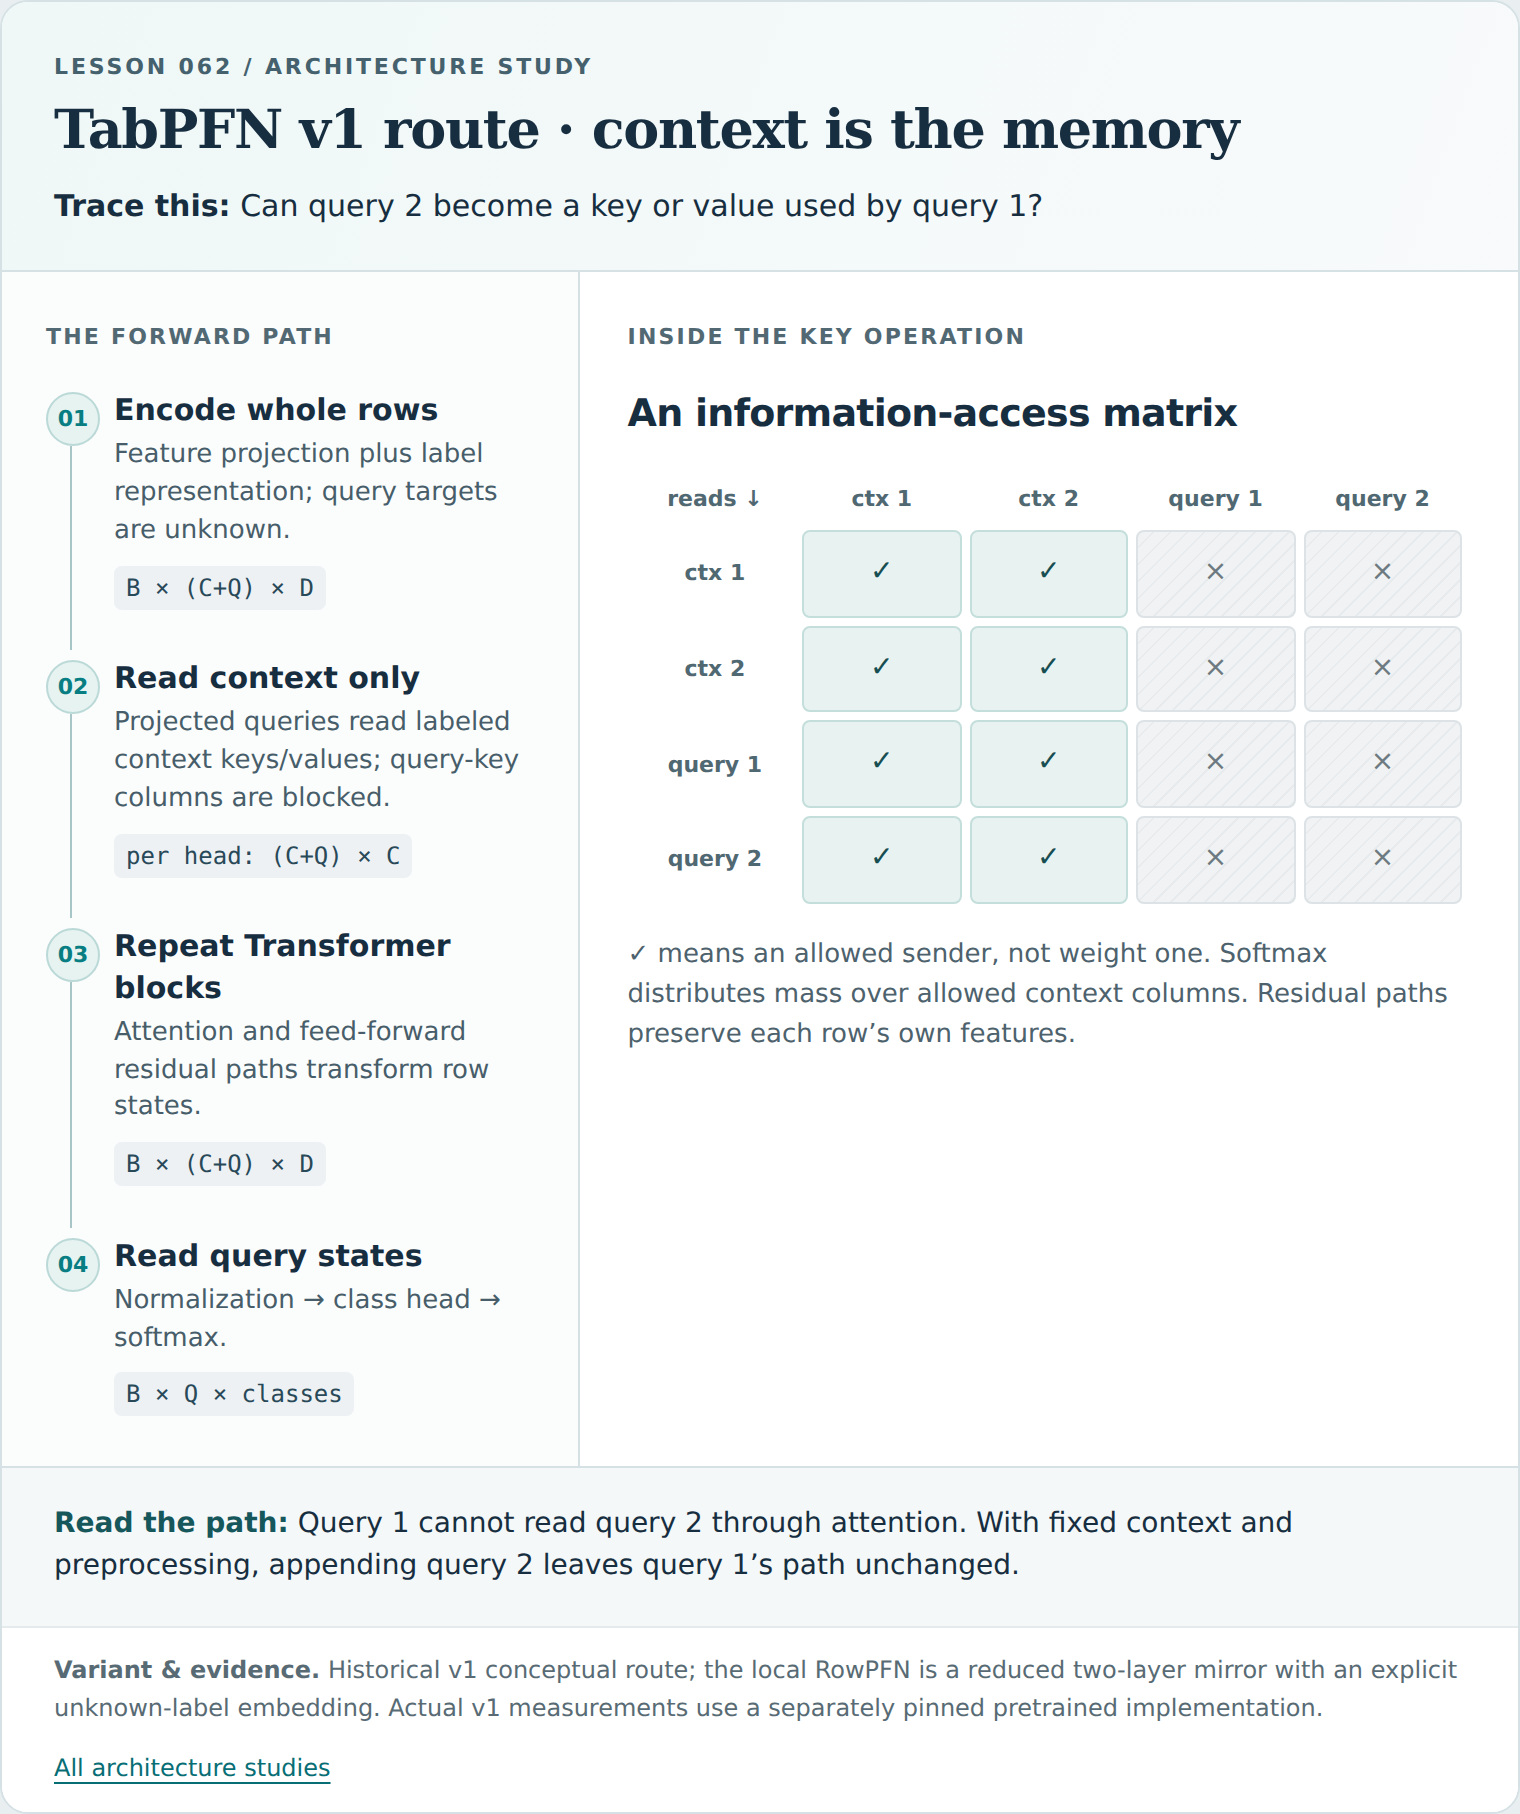</div>

*Portable architecture figure. On a narrow notebook screen, scroll horizontally to retain readable labels.* [Open the responsive diagram](https://avistian.github.io/relational/labs/html/architecture-review/0062-rowpfn.html).

**Read the path:** Query 1 cannot read query 2 through attention. With fixed context and preprocessing, appending query 2 leaves query 1’s path unchanged.

**Variant and evidence:** Historical v1 conceptual route; the local RowPFN is a reduced two-layer mirror with an explicit unknown-label embedding. Actual v1 measurements use a separately pinned pretrained implementation.

## Trace information access before tracing numbers

With three context rows and two queries, the attention-allow matrix has five rows and five columns. Every row may read the first three columns. The last two columns are blocked. Thus context representations depend only on context, while each query can read context and retain its own features through residual paths. Queries do not read one another's target or feature tokens through row attention.

This rule produces two useful invariances. Reordering context features and labels together should preserve a query's prediction in the position-free reduced model. Appending an unrelated query should not change the original query's prediction. Reordering features is different: v1's row encoder has feature-coordinate-specific weights, and preprocessing/permutation ensembling complicates full-system invariance. Do not infer a feature-order theorem from a row-order test.

### Attention has receivers, senders and payloads

For a projected query q and context keys kᵢ, attention forms scores q·kᵢ/√d_head. Softmax converts those scores into nonnegative weights summing to one over allowed senders. The output is the weighted sum of context value vectors vᵢ. Keys determine relevance; values carry the information being aggregated.

If the two allowed scores are 0 and ln 3, their weights are 1/4 and 3/4. With scalar values 2 and 6, the output is 5. Replacing the second value by 10 while holding scores fixed changes the output to 8. Replacing a key could instead change both weights. These interventions isolate different parts of the computation.

With C context rows and Q query rows, the conceptual allow-mask has shape (C+Q)×(C+Q). Every receiver may read the first C sender columns. All query sender columns are blocked. An implementation may avoid materializing blocked columns and directly use only context keys/values; the information graph is the same.

Mask conventions differ across APIs. In the local function, True means allowed. A library that uses True to mean blocked requires inversion. This error can preserve tensor shapes and produce finite outputs while reversing the intended information boundary. Check a tiny matrix before training.

Fully blocked rows are invalid for ordinary softmax attention because their scores become all negative infinity. The local implementation rejects them. Do not patch the resulting NaNs by replacing them with zeros without defining what the model should do in an empty-memory situation.

### Why query isolation survives repeated layers

In the first layer, context states read only context states, so they cannot incorporate query information. Each query reads that context and retains its own features through residual paths. In the next layer, the context is still query-independent. Inductively, appending an unrelated query cannot change an existing query's path through these masked blocks.

This argument assumes fixed preprocessing, deterministic evaluation and the stated mask in every layer. A transform estimated from all query rows, dropout left active or an unmasked auxiliary stage can violate the premise. The empirical alone-versus-batched check tests the measured path, not every possible inference setting.

### Reordering context is different from replacing it

In the reduced position-free row model, permuting context rows and their labels together should preserve query predictions. The keys and values are merely reordered. For one query, the score vector is permuted in the same way, softmax permutes its weights, and the weighted sum returns the same vector.

In matrix form, if P permutes context rows, keys become PK and values PV. The query's score row becomes sPᵀ; its normalized weights become softmax(s)Pᵀ. Multiplying by PV cancels the permutation because PᵀP=I. This argument extends through the declared position-free masked blocks.

Permuting features without the corresponding feature encoder is a different intervention. A row projection assigns different weights to different feature coordinates, so exchanging their values can change the represented row. Context-row symmetry does not imply feature-column symmetry.

Replacing a context row also differs from reordering it. Replacement changes the evidence, so a changed prediction is expected. Use separate tests for permutation consistency, query-batch isolation and context sensitivity. Together they check that the model ignores irrelevant ordering while still responding to legitimate information changes.

<div style="overflow-x:auto;max-width:100%">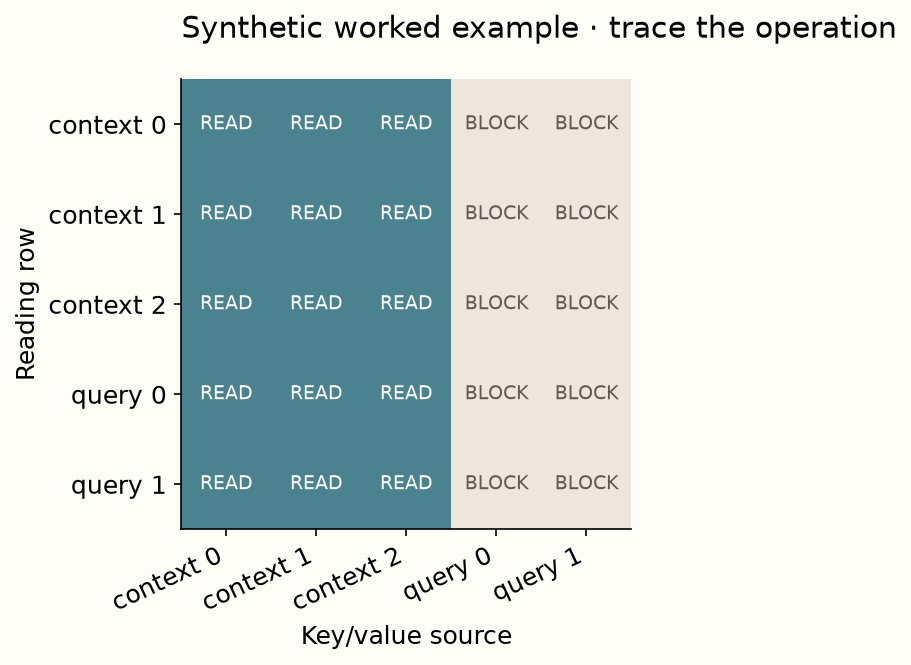</div>

*L062 mechanism: worked computation; see adjacent explanation. Scroll wide figures horizontally on small screens.*

For a query with scaled attention scores `[0, ln(2), 0]`, softmax weights are `[.25,.50,.25]`. Values `[−1,2,0]` give the weighted result `.75`. The values in a trained network are hidden vectors, not necessarily labels or probabilities. This one-coordinate example exposes the weighted sum; it does not reduce TabPFN to a nearest-neighbor classifier. Your attention implementation is checked against PyTorch's scaled-dot-product operation, and the released v1 layer provides a separate reference for context/query masking.

## Run the historical model explicitly

The notebook's reference path uses `tabpfn==0.1.11` and a SHA256-verified v1 checkpoint, in a separate environment from Nature v2. The historical package needs a documented typing-import compatibility shim with the current PyTorch version; it does not alter tensor operations. The checkpoint contains Python-serialized configuration objects, so its loader is enabled only after checking the pinned artifact identity.

The author experiment uses diabetes, blood transfusion and phoneme, each capped at 300 rows with 180 context rows, 60 validation rows and 60 test rows. One ensemble view and three seeds are used. These seeds describe inference configuration variability; they are not three independently pretrained foundation models. Preprocessing and optional view choices can dominate that variation.

### Reproduce a version, not a moving package name

“TabPFN” now refers to a family of versions and inference procedures. A historical v1 lesson must identify the package/code revision, checkpoint, preprocessing settings, ensemble views and supported task regime used in its measurements. Installing the latest package and calling a class with the same name does not establish that historical identity.

Checkpoint parameters and inference code jointly define the predictor. A compatible-looking architecture with random weights is a mechanism exercise. A pinned pretrained checkpoint through its supported inference path is a measured reference model. Training a reduced RowPFN from scratch is a third experiment. Keep all three labels explicit.

Preprocessing can include transformations and permutations whose fitted scope matters. Context-only feature statistics preserve an inductive query contract; query-dependent statistics can introduce batch dependence even when attention itself is isolated. Record the active settings rather than assuming that the attention mask alone determines the whole system.

Class mapping also matters. The probability column associated with label 1 must remain aligned across datasets and saved predictions. If labels are remapped to contiguous indices for inference, retain the inverse mapping. Otherwise a valid probability array can be scored against the wrong event.

For the local benchmark, compare the historical checkpoint with a declared baseline under matched rows and selection rules. A small three-task panel can establish that the inference path ran and reveal local behavior. It does not reproduce the original paper's full benchmark or all supported operating limits.

<div style="overflow-x:auto;max-width:100%">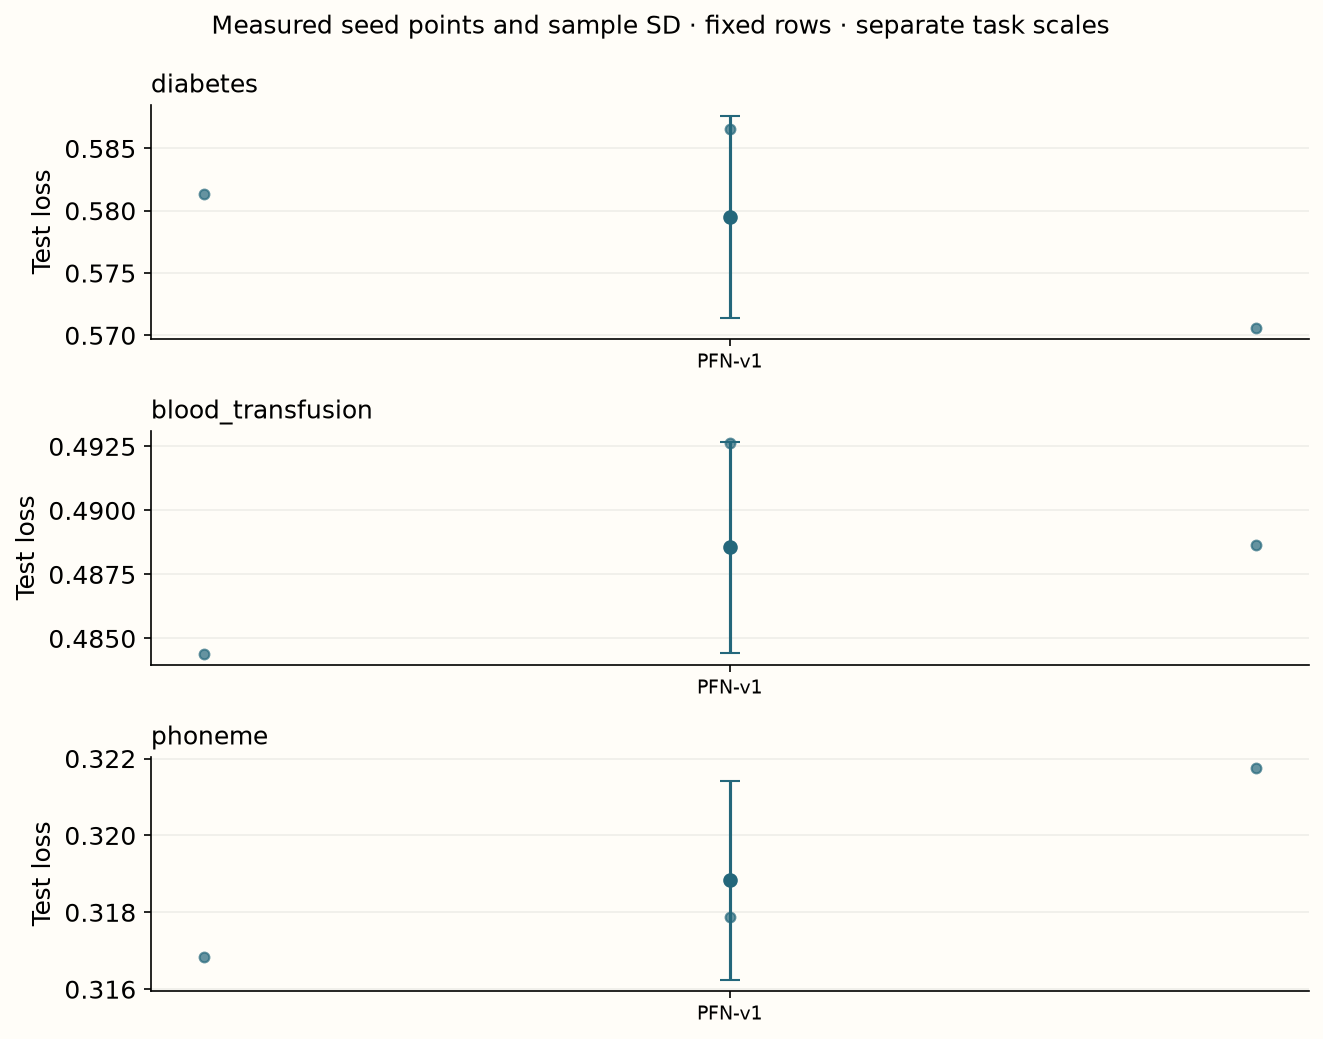</div>

*L062 results: author-reference measurements, separate from your kernel. Scroll wide figures horizontally on small screens.*

The experiment also compares a query predicted alone with the same query predicted alongside unrelated rows. This tests the whole observed inference path, including preprocessing. A source-level attention mask alone cannot prove that upstream normalization or later ensembling is independent of query batch composition. Inspect both tests and report their precise scopes.

## What “a second” leaves out

Separate checkpoint download and loading, context preparation, preprocessing, forward passes, ensemble views and any GPU synchronization. A warm prediction measurement is not a cold-start service measurement. Offline pretraining is amortized across future tasks; it is economically real even when excluded from a downstream latency comparison. The paper's speed claims use its declared hardware, tasks and competitors, so the local CPU timings are not reproductions of those numbers.

### A fast forward pass is one part of a prediction job

Separate cold loading, preprocessing/context preparation and query prediction. Loading weights from disk or downloading them can dominate the first call. Reusing a loaded model can make later calls much faster. Both timings are useful, but they describe different deployment situations.

Context length affects how much information the model reads and how much attention work it performs. Query batch size affects throughput and peak memory. More ensemble views can improve robustness while multiplying inference work. A single latency number without these settings is difficult to transfer to another workload.

If an implementation caches context representations, distinguish cache construction from reuse. The cache is valid only for the context, preprocessing and model state that produced it. Changing labels, feature order or checkpoint weights can require rebuilding it.

Measure quality and latency on the same declared procedure. Reporting the quality of many ensemble views beside the latency of one view combines different systems. Similarly, a timer that excludes preprocessing should not be described as end-to-end prediction cost.

For the exit artifact, show the mask fixture, the query-isolation check and the actual checkpoint identity. Then report one local quality/cost trade-off with its limits. The goal is to explain why the path works and what was measured, not to repeat a speed phrase without its denominator.

## Exit: defend the mask and the measured path

Implement the allow-mask and scaled attention, prove query isolation with an adversarial appended row, and run the reduced model on real numeric rows. Then regenerate or audit the historical checkpoint predictions. Submit model/package/checkpoint identities, context/test row IDs, log loss and timing, and a sentence identifying which code produced the score. Explain why an untrained reduced RowPFN passing invariance tests does not reproduce TabPFN's accuracy.

## Reproduction contract and task support

The visible code below implements the named operator or reduced architecture. The full pretrained model is a separately pinned reference path. Real public-table experiments use Tier A data; synthetic coin/SCM/shift tasks are Tier C mechanism isolation. Seeds, row identities, recipe budgets, versions and source/checkpoint hashes are available in the linked contract and evidence. Numerical agreement with a local operator is not a paper-table reproduction.

In [ ]:
# PROVIDED — environment, peripheral data/metric utilities
import os, sys, math, copy, re, json, hashlib, time, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from torch import nn
from scipy.stats import rankdata, friedmanchisquare, studentized_range, t
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
from sklearn.model_selection import StratifiedKFold
from threadpoolctl import threadpool_limits
from IPython.display import display
for directory in [Path.cwd(), Path.cwd()/'labs', Path.cwd().parent]:
    if (directory/'relkit').is_dir():
        ROOT=directory.resolve(); sys.path.insert(0,str(ROOT)); break
else:
    raise RuntimeError('Run the Colab bootstrap or start in the course repository')
torch.set_num_threads(1)
from relkit.foundation_benchmark import random_task, encode_train
print('CPU mechanism track; official checkpoint reruns use an isolated subprocess after EXIT.')

In [ ]:
# PROVIDED — AttentionBlock; inspect the live function calls
class AttentionBlock(nn.Module):
    """Pre-normalized multihead attention plus residual feed-forward block."""
    def __init__(self, width, heads):
        super().__init__()
        if width % heads:
            raise ValueError('Width must be divisible by heads')
        self.heads = heads
        self.norm1, self.norm2 = nn.LayerNorm(width), nn.LayerNorm(width)
        self.qkv, self.out = nn.Linear(width, 3*width), nn.Linear(width, width)
        self.ff = nn.Sequential(nn.Linear(width, 2*width), nn.GELU(), nn.Linear(2*width, width))

    def forward(self, x, allowed=None):
        b, n, d = x.shape
        q, k, v = [a.reshape(b,n,self.heads,d//self.heads).transpose(1,2)
                   for a in self.qkv(self.norm1(x)).chunk(3,-1)]
        h = attention(q,k,v,allowed).transpose(1,2).reshape(b,n,d)
        x = x + self.out(h)
        return x + self.ff(self.norm2(x))

In [ ]:
# PROVIDED — RowPFN; inspect the live function calls
class RowPFN(nn.Module):
    """Reduced row-token PFN. Labels are embedded only for context rows.

    Shapes: context [B,C,F], query [B,Q,F], labels [B,C], logits [B,Q,2].
    No positions: simultaneous context row/label permutation leaves predictions fixed.
    """
    def __init__(self, features, width=32, heads=4, layers=2):
        super().__init__()
        self.x_encoder = nn.Linear(features,width)
        self.y_encoder = nn.Embedding(3,width)  # 0,1 plus an explicit unknown symbol
        self.blocks = nn.ModuleList([AttentionBlock(width,heads) for _ in range(layers)])
        self.head = nn.Sequential(nn.LayerNorm(width),nn.Linear(width,2))

    def embeddings(self, context, labels, query):
        c, q = context.shape[1], query.shape[1]
        h = self.x_encoder(torch.cat([context,query],1))
        unknown = torch.full((len(context),q),2,dtype=torch.long,device=context.device)
        h = h + self.y_encoder(torch.cat([labels.long(),unknown],1))
        allow = context_mask(c,q).to(context.device)
        for block in self.blocks:
            h = block(h,allow)
        return h[:,c:]

    def forward(self, context, labels, query):
        return self.head(self.embeddings(context,labels,query))

## TODO 1 · context_mask

**Goal:** Return a Boolean allow-mask where every row can read context and none can read query keys.

**Why it matters:** a wrong implementation can produce a plausible-looking experiment while violating this lesson's prediction contract. Before coding, name one input that should fail or one intervention that should leave the result unchanged.

**Hint boundary:** reason from the worked example and the function contract; the CHECK verifies behavior, not a required code layout.

In [ ]:
# TODO 1 — context_mask
def context_mask(n_context, n_query):
    raise NotImplementedError("Implement the stated operation")

In [ ]:
# CHECK 1 — context_mask
mask=context_mask(3,2)
assert mask.dtype==torch.bool and mask.shape==(5,5)
assert mask[:,:3].all() and not mask[:,3:].any(), 'Query columns must never supply context keys'

print("PASS: context_mask")

## TODO 2 · attention

**Goal:** Implement scaled scores, optional allow-mask, normalized weights and value aggregation. Reject fully blocked rows.

**Why it matters:** a wrong implementation can produce a plausible-looking experiment while violating this lesson's prediction contract. Before coding, name one input that should fail or one intervention that should leave the result unchanged.

**Hint boundary:** reason from the worked example and the function contract; the CHECK verifies behavior, not a required code layout.

In [ ]:
# TODO 2 — attention
def attention(q, k, v, allowed=None):
    raise NotImplementedError("Implement the stated operation")

In [ ]:
# CHECK 2 — attention
torch.manual_seed(62)
q,k,v=torch.randn(2,3,4),torch.randn(2,5,4),torch.randn(2,5,6)
allowed=torch.tensor([[True,True,False,True,False]]).expand(3,5)
torch.testing.assert_close(attention(q,k,v,allowed),nn.functional.scaled_dot_product_attention(q,k,v,attn_mask=allowed))
changed=v.clone();changed[:,2]=1000;changed[:,4]=-1000
torch.testing.assert_close(attention(q,k,v,allowed),attention(q,k,changed,allowed),msg='Blocked values changed the output')

print("PASS: attention")

## Run your live implementation

Predict the outcome before execution. This cell calls the functions you just wrote. Changing a TODO must change the corresponding computation or make a CHECK fail. The text printed with the result identifies whether this is a small training run, a mechanism test or a reanalysis of committed measurements.

In [ ]:
# PROVIDED — experiment driven by your live functions
raw,y,reg,audit=random_task('diabetes',cap=120,seed=62);x=encode_train(raw)
scale=StandardScaler().fit(x['train']);cx=torch.tensor(scale.transform(x['train']),dtype=torch.float32)[None]
qx=torch.tensor(scale.transform(x['test'][:4]),dtype=torch.float32)[None];cy=torch.tensor(y['train'])[None]
torch.manual_seed(62);model=RowPFN(cx.shape[-1]).eval();p=model(cx,cy,qx)
torch.testing.assert_close(p[:,:1],model(cx,cy,qx[:,:1]),atol=1e-6,rtol=1e-5)
p.sum().backward();assert model.x_encoder.weight.grad.abs().sum()>0
trial={'shape':list(p.shape),'scope':'untrained real-row mechanism and gradient check, not pretrained accuracy'}
print(trial)

## Audit author-reference evidence

Inspect the measured results below independently of your smoke experiment. A fresh smoke may use a smaller budget. Preserve the protocol difference rather than forcing numerical agreement with a different run. The committed prediction arrays let you reconstruct scores without downloading pretrained weights.

In [ ]:
# PROVIDED — readable evidence, never impersonating current-kernel training
author=json.loads((ROOT/'_verify_l062_results.json').read_text())
print('AUTHOR REFERENCE:',author.get('scope',author.get('note','Declared checkpoint experiment')))
print('Evidence verdict:',author.get('verdict'))
rows=author.get('records',author.get('summary',[]))
if isinstance(rows,list) and rows:
    display(pd.DataFrame(rows).drop(columns=['predictions','targets','history','context_ids','task_losses'],errors='ignore').head(24))
if 62 in [60,70]:
    for regime,summary in author['summary'].items():
        print(regime,summary['mean_ranks'],'Friedman p=',summary['friedman_p'],'CD=',summary['nemenyi_cd'])

## EXIT TICKET · submit an executable argument

Provide your code output plus a 30–100 word verdict: which implementation ran, what information it could use, what evidence supports the result, and which paper claim remains untested. Include an unexpected or failed case and a next discriminating experiment. The length check below only enforces an attempt; the tutor grades your reasoning. Do not infer personal mastery from a green code cell.

In [ ]:
# TODO — written verdict; paste the resulting artifact and explanation to the tutor
verdict=''
assert len(verdict.split())>=30, 'Write a defensible verdict; a passing code cell is not the explanation'
ticket={'lesson':62,'checks':'passed in this kernel','trial':trial,'verdict':verdict,
        'paper_reproduction':'NOT_ESTABLISHED','author_reference':'_verify_l062_results.json'}
folder=ROOT/'data/cache/foundation';folder.mkdir(parents=True,exist_ok=True)
path=folder/'student-l062-exit.json'
path.write_text(json.dumps(ticket,indent=2,default=lambda x:x.item() if hasattr(x,'item') else x.tolist(),allow_nan=False)+'\n')
print('EXIT artifact:',path)

## NEXT STEP · reproduce or scale the declared track

Read [the exact reproduction contract](l062-reproduction.md) before increasing resources. The gate below invokes the shared runner in a subprocess; historical versions are installed into isolated package directories so v1 and v2 cannot silently replace one another. It may download the pinned checkpoint. Larger runs remain INCOMPARABLE wherever material paper-protocol gaps remain. A full paper preset deliberately fails until the original protocol is implemented.

For unattended CPU execution: `modal run --detach modal/foundation_repro.py --lesson 62 --preset closer`. This is a supplied operator, not evidence that a cloud job was run.

In [ ]:
# PROVIDED — explicit post-EXIT gate (OFF by default)
RUN_PAPER_REPRO=False
if RUN_PAPER_REPRO:
    import subprocess
    subprocess.run([sys.executable,str(ROOT/'_run_foundation.py'),'--lesson','62',
                    '--preset','closer','--output',str(ROOT/'data/cache/foundation/l062-closer.json')],check=True)
else:
    print('Scale-up NOT_RUN in this kernel. See the protocol ledger before enabling.')